# sarima_code

SARIMA es el modelo estadístico univariante de referencia. En datos turísticos mensuales, el periodo estacional es 12. La celda descompone la serie de entrenamiento, examina el comportamiento ACF/PACF, selecciona los parámetros mediante `auto_arima` y AIC, comprueba los residuos con Ljung-Box y evalúa el periodo reservado para la prueba.

Para mantener la comparación honesta con los otros modelos (que en cada
mes de test usan solo información real conocida hasta el mes anterior, sin
acumular su propio error), aquí se implementa una validación walk-forward
ONE-STEP-AHEAD: el modelo se ajusta con el histórico y, para cada mes de
test, se actualiza con las observaciones reales ya conocidas (sin volver a
reestimar los parámetros) y se predice
únicamente el mes siguiente.

Salida: Índice de Presión Turística (IPT) - proxy con 3 niveles de alerta
        Verde (menos grave) -> Naranja -> Rojo (más grave)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip -q install pmdarima statsmodels scikit-learn matplotlib pandas numpy


>> Ejecutando Optimización (búsqueda amplia + afinado)...


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Orden SARIMA seleccionado: (3, 0, 2) x (1, 0, 0, 12) (AIC=2451.3)


         MÉTRICAS DE ERROR (TEST SET)
MAE (Error Absoluto Medio): 138,659 pernoctaciones
RMSE (Raíz del Error Cuadrático Medio): 163,023
MAPE (Error Porcentual Absoluto Medio): 5.13%
R2 (Coeficiente de Determinación): 0.9558


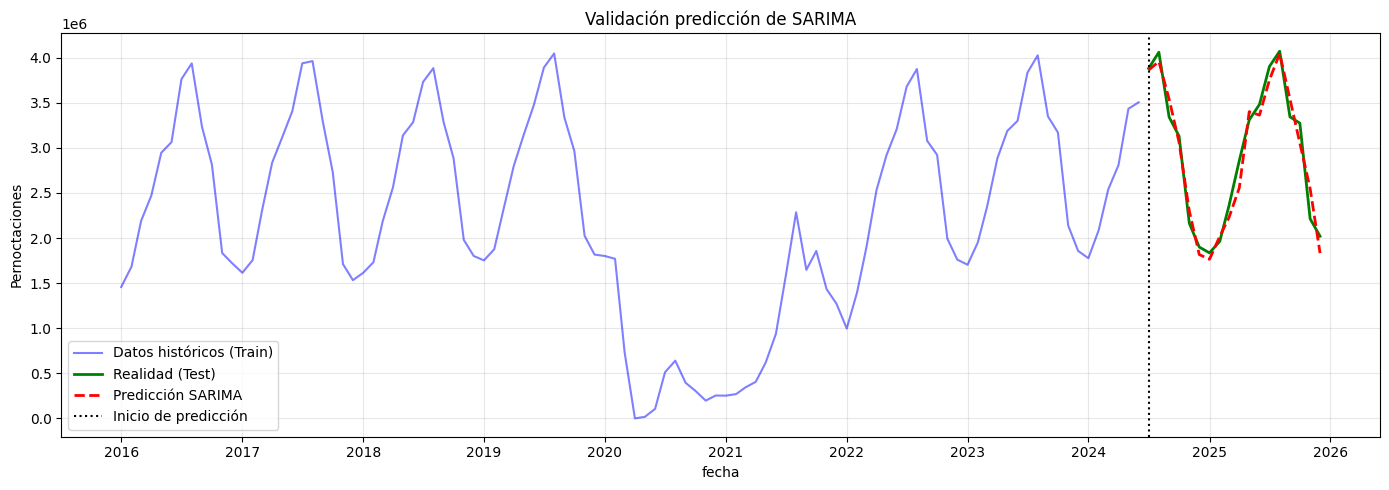

 PRECISIÓN DE LA CLASIFICACIÓN SEMÁFORO (IPT)
Umbral Verde/Naranja: 1,834,345 pernoctaciones
Umbral Naranja/Rojo:  3,018,909 pernoctaciones
Aciertos de nivel de alerta: 83.3% (15/18 meses)

fecha_objetivo  pernoctaciones_real  pernoctaciones_predicha ipt_real  codigo_real ipt_predicho  codigo_predicho  acierto_nivel
    2024-07-01              3881922             3.862290e+06     Rojo            2         Rojo                2           True
    2024-08-01              4061207             3.958990e+06     Rojo            2         Rojo                2           True
    2024-09-01              3341674             3.540069e+06     Rojo            2         Rojo                2           True
    2024-10-01              3130930             3.062151e+06     Rojo            2         Rojo                2           True
    2024-11-01              2164179             2.299441e+06  Naranja            1      Naranja                1           True
    2024-12-01              1900241       

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. CARGA DE DATOS (SERIE UNIVARIANTE)
RUTA_DATOS = "/content/drive/MyDrive/VIU/TFM/Data/DATASET_TFM_FINAL.csv"
TARGET = "Pernoctaciones"
MESES_TEST = 18   # misma ventana de test que XGBoost / RF / Regresión Lineal

df = pd.read_csv(RUTA_DATOS, parse_dates=["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)
df = df.set_index("fecha")
df.index.freq = "MS"  # frecuencia mensual explícita, necesaria para SARIMAX

y_abs = df[TARGET]
y_train = y_abs.iloc[:-MESES_TEST]
y_test = y_abs.iloc[-MESES_TEST:]

# 2. OPTIMIZACIÓN DEL ORDEN SARIMA (equivalente a la doble optimización de los modelos de ML: búsqueda amplia -> afinado)

# FASE 1: búsqueda amplia con auto_arima (equivalente a RandomizedSearchCV): explora (p,d,q)(P,D,Q,12) minimizando AIC sobre el conjunto de entrenamiento.
print(">> Ejecutando Optimización (búsqueda amplia + afinado)...")
busqueda_amplia = pm.auto_arima(
    y_train,
    seasonal=True, m=12,
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=2, max_Q=2,
    max_d=2, max_D=1,
    stepwise=False, trace=False,
    error_action="ignore", suppress_warnings=True,
    information_criterion="aic",
)
orden_amplio = busqueda_amplia.order
orden_estacional_amplio = busqueda_amplia.seasonal_order

# FASE 2: afinado (equivalente a GridSearchCV) alrededor del mejor orden, explorando variaciones pequeñas de (p,q) y (P,Q) y quedándonos con el AIC más bajo real ajustando SARIMAX directamente (más fiel al modelo final).
p0, d0, q0 = orden_amplio
P0, D0, Q0, s0 = orden_estacional_amplio

mejor_aic = np.inf
mejor_orden, mejor_orden_estacional = orden_amplio, orden_estacional_amplio

for p in {max(0, p0 - 1), p0, p0 + 1}:
    for q in {max(0, q0 - 1), q0, q0 + 1}:
        for P in {max(0, P0 - 1), P0}:
            for Q in {max(0, Q0 - 1), Q0}:
                try:
                    modelo_prueba = SARIMAX(
                        y_train, order=(p, d0, q),
                        seasonal_order=(P, D0, Q, s0),
                        enforce_stationarity=False, enforce_invertibility=False,
                    ).fit(disp=False)
                    if modelo_prueba.aic < mejor_aic:
                        mejor_aic = modelo_prueba.aic
                        mejor_orden, mejor_orden_estacional = (p, d0, q), (P, D0, Q, s0)
                except Exception:
                    continue

print(f"Orden SARIMA seleccionado: {mejor_orden} x {mejor_orden_estacional} (AIC={mejor_aic:.1f})\n")


# 3. VALIDACIÓN WALK-FORWARD ONE-STEP-AHEAD (horizonte = 1 mes)
modelo_base = SARIMAX(
    y_train, order=mejor_orden, seasonal_order=mejor_orden_estacional,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

predicciones = []
fechas_pred = []
resultado_actual = modelo_base

for fecha_objetivo in y_test.index:
    # Predicción a 1 paso vista usando solo información disponible hasta el momento
    pred_1paso = resultado_actual.get_forecast(steps=1).predicted_mean.iloc[0]
    predicciones.append(pred_1paso)
    fechas_pred.append(fecha_objetivo)

    # Se incorpora la observación REAL de ese mes (ya conocida al llegar al siguiente) sin reestimar parámetros (refit=False), tal y como se operaría en producción mes a mes.
    nuevo_valor = y_abs.loc[[fecha_objetivo]]
    resultado_actual = resultado_actual.append(nuevo_valor, refit=False)

predicciones_abs = pd.Series(predicciones, index=fechas_pred)
y_test_abs = y_test

# 4. MÉTRICAS DE EVALUACIÓN FINAL (HORIZONTE 1 MES)
mae = mean_absolute_error(y_test_abs, predicciones_abs)
rmse = np.sqrt(mean_squared_error(y_test_abs, predicciones_abs))
mape = np.mean(np.abs((y_test_abs - predicciones_abs) / y_test_abs)) * 100
r2 = r2_score(y_test_abs, predicciones_abs)

print("\n" + "="*40)
print("         MÉTRICAS DE ERROR (TEST SET)")
print("="*40)
print(f"MAE (Error Absoluto Medio): {mae:,.0f} pernoctaciones")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:,.0f}")
print(f"MAPE (Error Porcentual Absoluto Medio): {mape:.2f}%")
print(f"R2 (Coeficiente de Determinación): {r2:.4f}")

# 5. VISUALIZACIÓN
plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train, label='Datos históricos (Train)', color='blue', alpha=0.5)
plt.plot(y_test_abs.index, y_test_abs, label='Realidad (Test)', color='green', linewidth=2)
plt.plot(predicciones_abs.index, predicciones_abs, label='Predicción SARIMA', color='red', linestyle='--', linewidth=2)
plt.axvline(x=y_test_abs.index[0], color='black', linestyle=':', label='Inicio de predicción')
plt.title('Validación predicción de SARIMA')
plt.ylabel('Pernoctaciones')
plt.xlabel('fecha')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("sarima_h1_ipt_final.png", dpi=110)
plt.show()


# 6. ÍNDICE DE PRESIÓN TURÍSTICA (IPT) - 3 NIVELES DE ALERTA
# Mismos umbrales (P33/P66 del histórico completo) que en XGBoost, Random Forest y Regresión Lineal, para que los cuatro modelos sean comparables.
UMBRAL_VERDE_NARANJA, UMBRAL_NARANJA_ROJO = np.percentile(y_abs, [33, 66])

NIVELES_IPT = {0: "Verde", 1: "Naranja", 2: "Rojo"}


def clasificar_ipt(valor_pernoctaciones):
    """Devuelve (nivel_texto, codigo_numerico) donde 0=Verde (menos grave)
    y 2=Rojo (más grave)."""
    if valor_pernoctaciones < UMBRAL_VERDE_NARANJA:
        codigo = 0
    elif valor_pernoctaciones < UMBRAL_NARANJA_ROJO:
        codigo = 1
    else:
        codigo = 2
    return NIVELES_IPT[codigo], codigo


# 6.1 Alertas IPT sobre todo el conjunto de test
alertas_test = pd.DataFrame({
    "fecha_objetivo": y_test_abs.index,
    "pernoctaciones_real": y_test_abs.values,
    "pernoctaciones_predicha": predicciones_abs.values,
})
alertas_test[["ipt_real", "codigo_real"]] = alertas_test["pernoctaciones_real"].apply(
    lambda v: pd.Series(clasificar_ipt(v))
)
alertas_test[["ipt_predicho", "codigo_predicho"]] = alertas_test["pernoctaciones_predicha"].apply(
    lambda v: pd.Series(clasificar_ipt(v))
)
alertas_test["acierto_nivel"] = alertas_test["codigo_real"] == alertas_test["codigo_predicho"]

precision_semaforo = alertas_test["acierto_nivel"].mean() * 100
print("=" * 45)
print(" PRECISIÓN DE LA CLASIFICACIÓN SEMÁFORO (IPT)")
print("=" * 45)
print(f"Umbral Verde/Naranja: {UMBRAL_VERDE_NARANJA:,.0f} pernoctaciones")
print(f"Umbral Naranja/Rojo:  {UMBRAL_NARANJA_ROJO:,.0f} pernoctaciones")
print(f"Aciertos de nivel de alerta: {precision_semaforo:.1f}% ({alertas_test['acierto_nivel'].sum()}/{len(alertas_test)} meses)\n")
print(alertas_test.to_string(index=False))

# 6.2 Matriz de confusión entre niveles IPT
matriz_confusion = pd.crosstab(
    alertas_test["ipt_real"], alertas_test["ipt_predicho"],
    rownames=["Real"], colnames=["Predicho"]
).reindex(index=["Verde", "Naranja", "Rojo"], columns=["Verde", "Naranja", "Rojo"], fill_value=0)
print("\nMatriz de confusión (niveles IPT):")
print(matriz_confusion)

# 7. EXPORTAR RESULTADOS
resumen_metrico = pd.DataFrame([{
    "Modelo": f"SARIMA{mejor_orden}x{mejor_orden_estacional}",
    "Horizonte (meses)": 1,
    "MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2,
    "Precision_semaforo (%)": precision_semaforo,
}])
resumen_metrico.to_csv("resultados_sarima_ipt_h1.csv", index=False)
alertas_test.to_csv("alertas_ipt_h1_test_sarima.csv", index=False)
matriz_confusion.to_csv("matriz_confusion_ipt_h1_sarima.csv")

print("\nArchivos exportados: resultados_sarima_ipt_h1.csv, alertas_ipt_h1_test_sarima.csv, "
      "matriz_confusion_ipt_h1_sarima.csv, sarima_h1_ipt_final.png")
